In [1]:
script = False
cluster = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from efficientnet_pytorch import EfficientNet
import joblib

from astropy.io import fits
from astropy.table import Table
from astropy.visualization import make_lupton_rgb

if(script):
    from tqdm import tqdm
else: 
    from tqdm.notebook import tqdm

plt.style.use('dark_background')

## ML Components 

In [2]:
num_workers = 0

transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

In [3]:
class ImageDataset(Dataset):
    """Dataset of Images, Data and Labels"""

    def __init__(self, images, data, labels, transform=None):
        """
        Create a PyTorch dataset from an array of images
		and an array of labels
        """
        super().__init__()
        self.images = images
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        new_image = image.transpose(1,2,0) 
        new_image = (new_image - new_image.min()) / (new_image.max() - new_image.min())
        new_image = Image.fromarray(np.uint8(255*new_image)).convert("RGB")

        label = self.labels[idx]
        
        data_point = self.data.iloc[idx].to_dict()
        sample = {'image': self.transform(new_image), 'label': label, 'img': image, 'data': data_point}
        return sample
    
    def normalize_image(self, image):
        image_g = (image[0]-np.mean(image[0]))/ np.std(image[0])
        image_r = (image[1]-np.mean(image[1]))/ np.std(image[1])
        image_i = (image[2]-np.mean(image[2]))/ np.std(image[2])

        image_g = (image_g-np.min(image_g))/ (np.max(image_g) - np.min(image_g))
        image_r = (image_r-np.min(image_r))/ (np.max(image_r) - np.min(image_r))
        image_i = (image_i-np.min(image_i))/ (np.max(image_i) - np.min(image_i))
        return(image_i, image_r, image_g)

In [4]:
class EfficientNetClass(nn.Module):
    
    def __init__(self, n_classes, pretrained=False):
        super(EfficientNetClass, self).__init__()
        if(not cluster):
            self.model = EfficientNet.from_pretrained('efficientnet-b0',  num_classes=n_classes)
            torch.save(self.model.state_dict(), 'initial_model.pt')
        else:
            self.model = EfficientNet.from_name('efficientnet-b0',  num_classes=n_classes)
            self.model.load_state_dict(torch.load('initial_model.pt'))
            
    def forward(self, x):
        x = self.model(x)
        return x

In [5]:
model = EfficientNetClass(n_classes=14, pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

name = 'Exp/exp4/model_tmp.pt'#'model.pt'#'other.pt' 
model.load_state_dict(torch.load(name, map_location=device, weights_only=True))

Loaded pretrained weights for efficientnet-b0


<All keys matched successfully>

## Util functions

In [6]:
def make_plot_all(images, column_data, Q=9, stretch=40, minimum=(0,0,0)):
    for i in range(len(images)):
        if(i%8 == 0):
            plt.figure(figsize=(12,2))
            for j in range(8):
                if(i+j > len(images)-1): break
                plt.subplot(1,8,j+1)
                title = '{:.2f}'.format(column_data.iloc[i+j])
                plt.title(title)
                rgb = make_lupton_rgb(images[i+j][2], images[i+j][1], images[i+j][0], 
                                    Q=Q, stretch=stretch, minimum=minimum)
                plt.imshow(rgb, aspect='equal')
                plt.xticks([], [])
                plt.yticks([], []) 
            plt.show() 
    plt.close() 


def q_theta_from_e1_e2(e1, e2):
    e = np.sqrt(e1**2 + e2**2)
    q = (1 - e) / (1 + e)
    theta = np.degrees(np.arctan2(e2, e1) / 2)
    return q, theta


## Rojas data

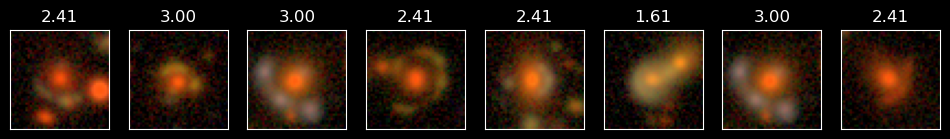

True columns kept:  Index(['RE', 'qm', 'PAm', 'phiext'], dtype='str')
torch.Size([59, 4])


In [7]:
#Rojas candidates 
filepath = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/data/candidates_tocompare/final_files/'
hdu_list = fits.open(filepath + 'Rojas_DES.fits')
images = hdu_list[1].data.astype(np.float32)
data = Table(hdu_list[2].data).to_pandas() #Data is not complete here, just in the right sort
hdu_list.close()

data_tmp = data.sample(8)
images_tmp = images[data_tmp.index]
make_plot_all(images_tmp, data_tmp['Exp_score'])

labels_dataset = data.drop(['COADD_OBJECT_ID', 'TILENAME', 'HPIX_4096', 'RA', 'DEC', 'Name',
       'Exp_score', 'n_Cand', 'rchi2', 'U_RE', 'L_RE', 'U_qm', 'L_qm', 'U_PAm', 'L_PAm', 'gammaext', 
        'U_gammaext', 'L_gammaext', 'U_phiext', 'L_phiext'], axis = 1) #Keep: 'RE', 'qm', 'PAm', later include uncertainties
print('True columns kept: ', labels_dataset.columns)
labels_dataset = torch.tensor(labels_dataset.values, dtype=torch.float32)
print(labels_dataset.shape)

dataset = ImageDataset(images, data, labels_dataset, transform=transform)
data_loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=1, num_workers=num_workers, shuffle=True)

In [8]:
data.head()

,COADD_OBJECT_ID,TILENAME,HPIX_4096,RA,DEC,Name,Exp_score,n_Cand,rchi2,RE,...,L_qm,PAm,U_PAm,L_PAm,gammaext,U_gammaext,L_gammaext,phiext,U_phiext,L_phiext
0,1056483458,DES0017-4123,145382565,4.818099,-41.614085,DES J001916-413650,1.183099,,1.18,2.061,...,0.019,81.0,7.0,7.0,0.053,0.008,0.008,-50.0,9.0,9.0
1,1054556683,DES0016-4623,144893579,3.928374,-46.603077,DES J001542-463610,3.000000,,0.98,2.353,...,0.020,-79.0,4.0,4.0,0.148,0.005,0.005,12.0,2.0,2.0
2,1084325867,DES0037-2541,68294465,9.593205,-25.842290,DES J003822-255032,0.591549,,1.13,2.470,...,0.022,-74.0,9.0,12.0,0.008,0.004,0.006,-64.0,29.0,50.0
3,1128511911,DES0102-4914,143536576,15.491890,-49.293948,DES J010158-491738,2.408451,,1.14,2.877,...,0.032,-48.0,7.0,7.0,0.140,0.010,0.008,-85.0,6.0,8.0
4,1620013669,DES0142-1832,149607078,25.720342,-18.521055,DES J014252-183115,2.408451,,1.19,2.347,...,0.020,79.0,3.0,4.0,0.079,0.007,0.008,-15.0,4.0,5.0


## Evaluating Performance

In [9]:
def testing_analysis(test_loader):
    predicted_data, true_data = [], []
    for i, sample in enumerate(tqdm(test_loader)):
        data, target, sample_img, sample_data = sample['image'], sample['label'] , sample['img'], sample['data']

        output = model.forward(data)
        output = output.detach().cpu().numpy()
        
        predicted_data.append(output[0])
        true_data.append(target.cpu().numpy()[0])

    scaler_y = joblib.load('scaler_y.joblib') #Applying inverse transformation to predicted data
    predicted_data = scaler_y.inverse_transform(predicted_data) 
    
    predicted_data = pd.DataFrame(predicted_data)
    true_data = pd.DataFrame(true_data)
    
    return(predicted_data, true_data)

predicted_data, true_data = testing_analysis(data_loader)

  0%|          | 0/59 [00:00<?, ?it/s]

In [10]:
# Formatting predicted and true dataframes
names = ['EINSTEIN_RADIUS', 'e1_lens', 'e2_lens', 'center_x_lens', 'center_y_lens', 'R_sersic_source_light',
       'n_sersic_source_light', 'e1_source_light', 'e2_source_light', 'center_x_source', 'center_y_source', 
        'R_sersic_lens_light', 'e1_lens_light', 'e2_lens_light']
column_mapping = {old_column: new_column for old_column, new_column in enumerate(names)}
predicted_data.rename(columns=column_mapping, inplace=True)

names = ['RE', 'qm', 'PAm', 'phiext']
column_mapping = {old_column: new_column for old_column, new_column in enumerate(names)}
true_data.rename(columns=column_mapping, inplace=True)

true_data.head()

,RE,qm,PAm,phiext
0,2.470,0.911,-74.0,-64.0
1,3.085,0.921,-3.0,-25.0
2,1.411,0.666,-86.0,-63.0
3,1.786,0.847,21.0,21.0
4,2.522,0.788,-11.0,-26.0


In [11]:
predicted_data.head()

,EINSTEIN_RADIUS,e1_lens,e2_lens,center_x_lens,center_y_lens,R_sersic_source_light,n_sersic_source_light,e1_source_light,e2_source_light,center_x_source,center_y_source,R_sersic_lens_light,e1_lens_light,e2_lens_light
0,3.589916,0.057830,-0.032213,0.000981,0.001556,0.842149,3.084281,0.006280,0.018442,0.301574,-0.145702,1.441332,0.007781,0.024794
1,3.893852,0.094116,0.092863,0.001125,0.000957,0.884803,2.899097,0.051891,0.033927,-0.155486,0.069274,1.517428,0.029818,0.046853
2,3.694722,0.182283,-0.015630,-0.000519,0.000889,0.800295,3.538703,-0.030963,0.000729,0.094628,-0.018552,1.241517,0.041351,0.047247
3,3.390876,0.147855,0.005632,-0.000656,0.001822,0.830087,3.028184,-0.019188,0.034697,0.078154,0.046328,1.359871,0.047458,0.000955
4,3.591229,0.079653,-0.059019,-0.001094,0.001816,0.864275,2.984713,0.009058,-0.007350,-0.069499,-0.284264,1.398259,0.057502,0.004616


In [12]:

q_list, phi_list = q_theta_from_e1_e2(predicted_data['e1_lens'], predicted_data['e2_lens'])
predicted_data['qm'], predicted_data['PAm'] = q_list, phi_list
predicted_data.rename(columns={'EINSTEIN_RADIUS': 'RE'}, inplace=True)


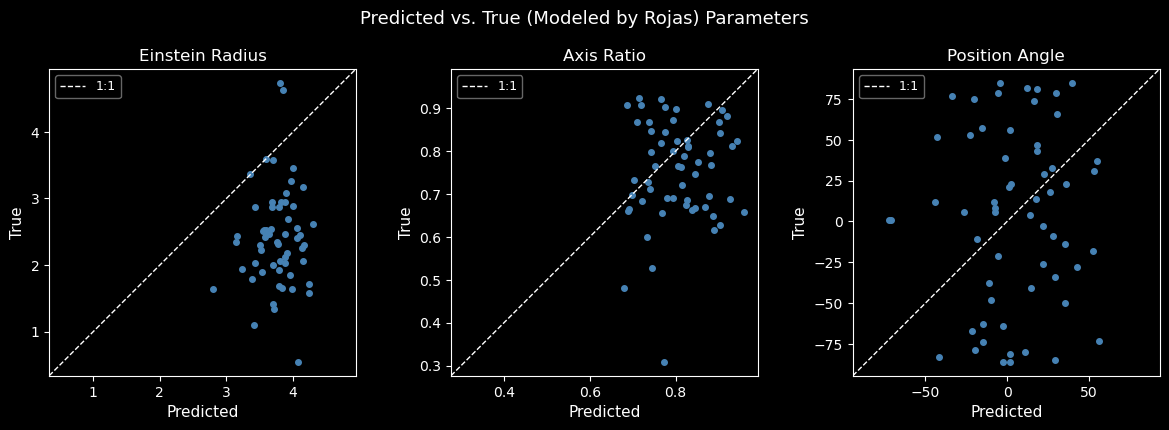

In [13]:
# I have three columns to compare: 'RE', 'qm', 'PAm'
titles = {'RE': 'Einstein Radius', 'qm': 'Axis Ratio', 'PAm': 'Position Angle'}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, column in zip(axes, titles):
    #yerr = [data['L_' + column], data['U_' + column]]
    #ax.errorbar(predicted_data[column], data[column], yerr=yerr, fmt='o', markersize=4, color='steelblue',
    #    ecolor='gray', elinewidth=0.8, capsize=3, capthick=0.8, alpha=1., linewidth=0)
    ax.plot(predicted_data[column], true_data[column], 'o', color='steelblue', ms=4)
    
    # 1:1 reference line
    all_vals = np.concatenate([predicted_data[column], true_data[column]])
    lims = [all_vals.min(), all_vals.max()]
    margin = (lims[1] - lims[0]) * 0.05
    lims = [lims[0] - margin, lims[1] + margin]
    ax.plot(lims, lims, 'w--', linewidth=1, alpha=1., label='1:1')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(titles[column], fontsize=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9, framealpha=0.5)

plt.suptitle('Predicted vs. True (Modeled by Rojas) Parameters', fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('figure.pdf', bbox_inches='tight', dpi=300)
plt.show()

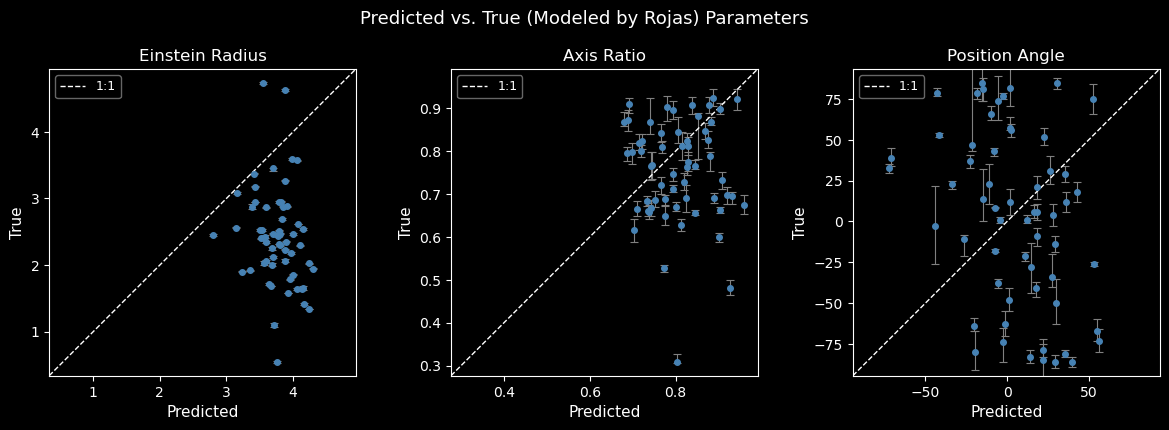

In [14]:
# WRONG?? I have three columns to compare: 'RE', 'qm', 'PAm'
titles = {'RE': 'Einstein Radius', 'qm': 'Axis Ratio', 'PAm': 'Position Angle'}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, column in zip(axes, titles):
    yerr = [data['L_' + column], data['U_' + column]]
    ax.errorbar(predicted_data[column], data[column], yerr=yerr, fmt='o', markersize=4, color='steelblue',
        ecolor='gray', elinewidth=0.8, capsize=3, capthick=0.8, alpha=1., linewidth=0)

    # 1:1 reference line
    all_vals = np.concatenate([predicted_data[column], data[column]])
    lims = [all_vals.min(), all_vals.max()]
    margin = (lims[1] - lims[0]) * 0.05
    lims = [lims[0] - margin, lims[1] + margin]
    ax.plot(lims, lims, 'w--', linewidth=1, alpha=1., label='1:1')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(titles[column], fontsize=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9, framealpha=0.5)

plt.suptitle('Predicted vs. True (Modeled by Rojas) Parameters', fontsize=13, y=1.02)
plt.tight_layout()
#plt.savefig('figure.pdf', bbox_inches='tight', dpi=300)
plt.show()

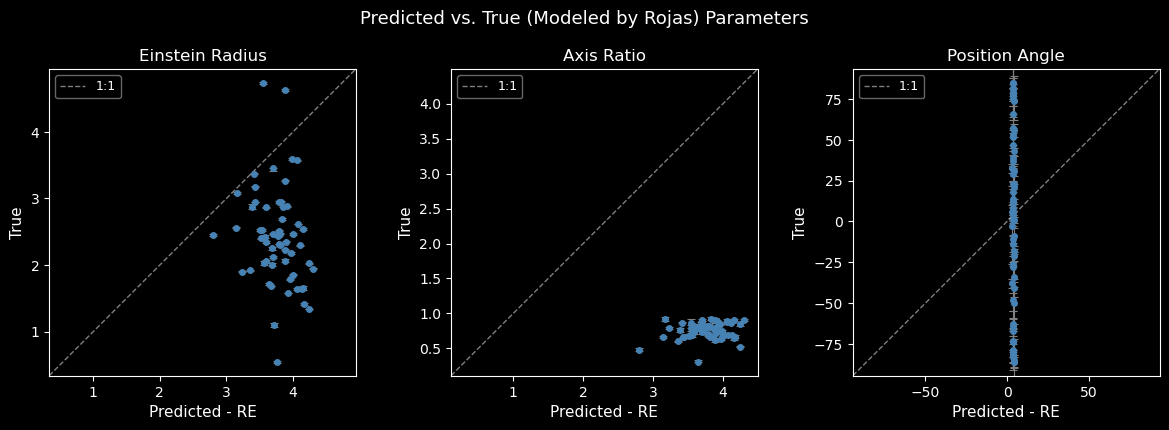

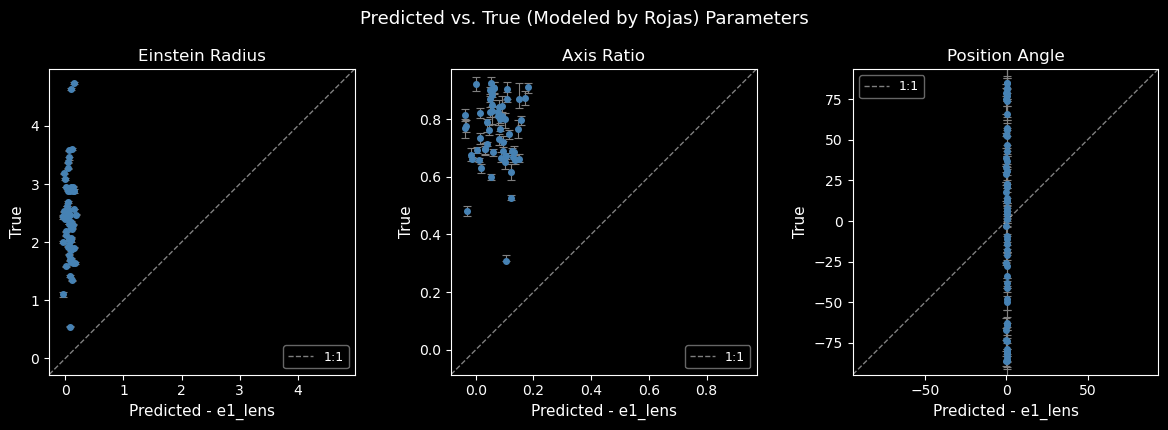

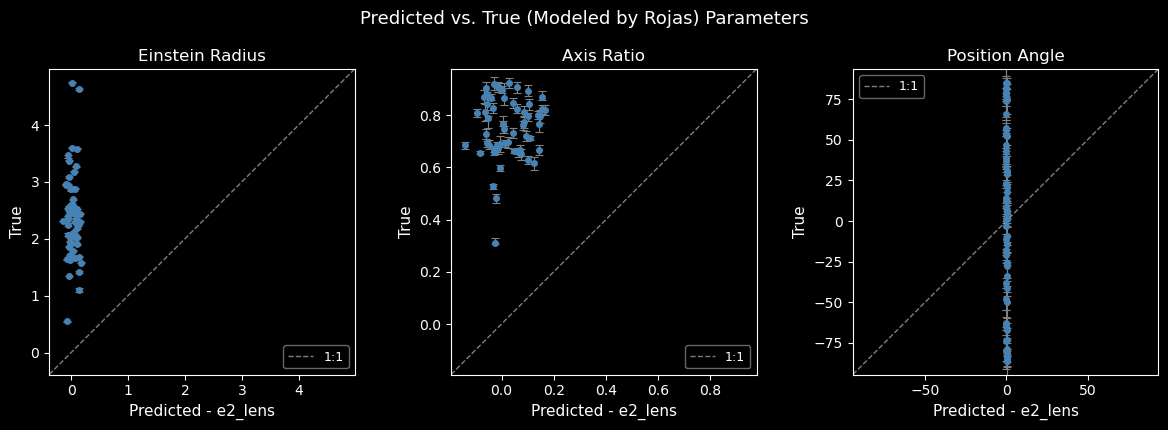

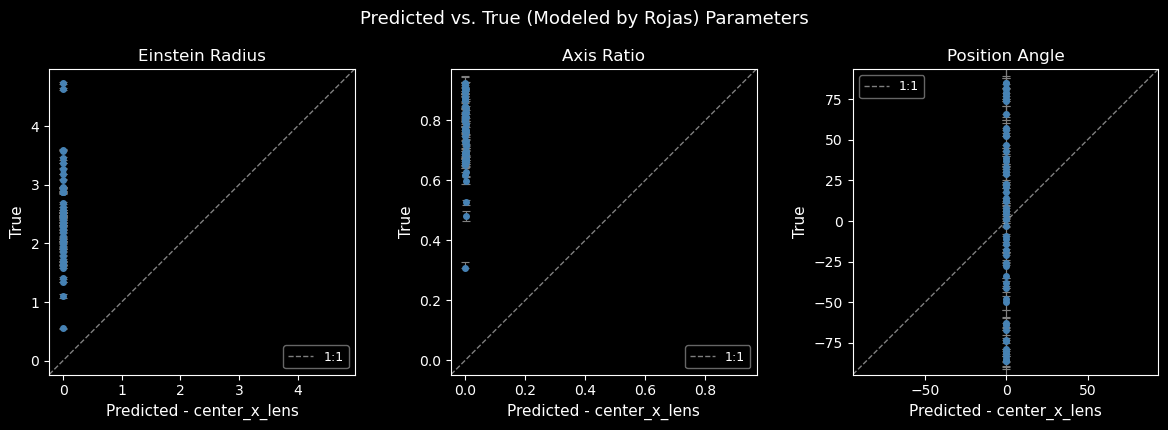

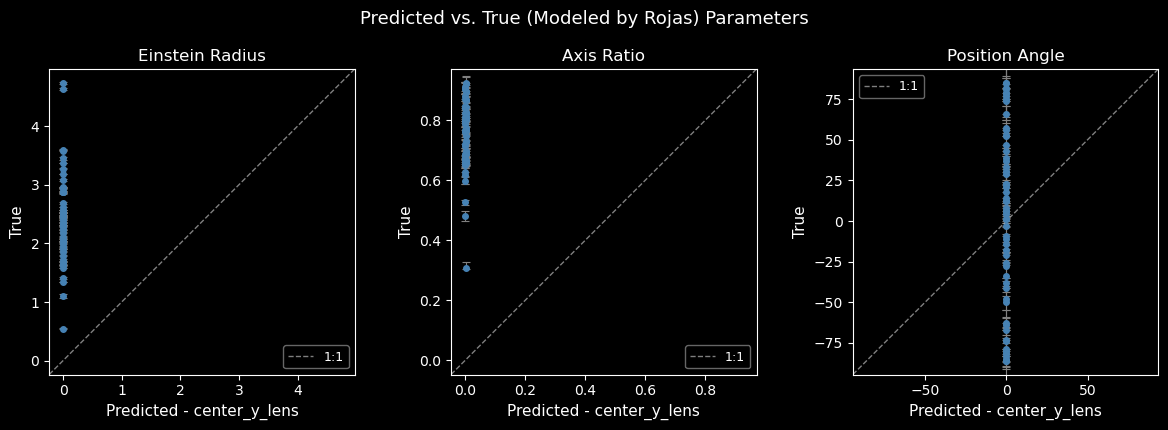

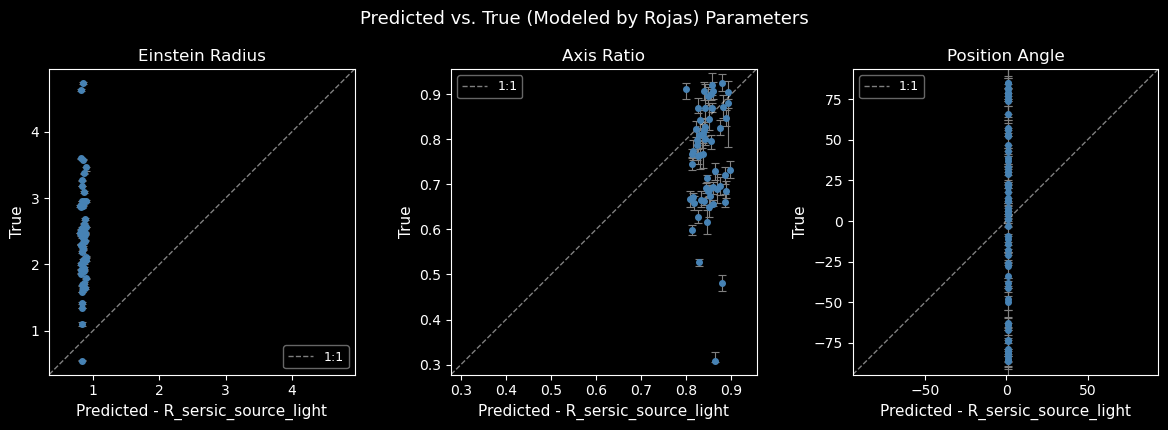

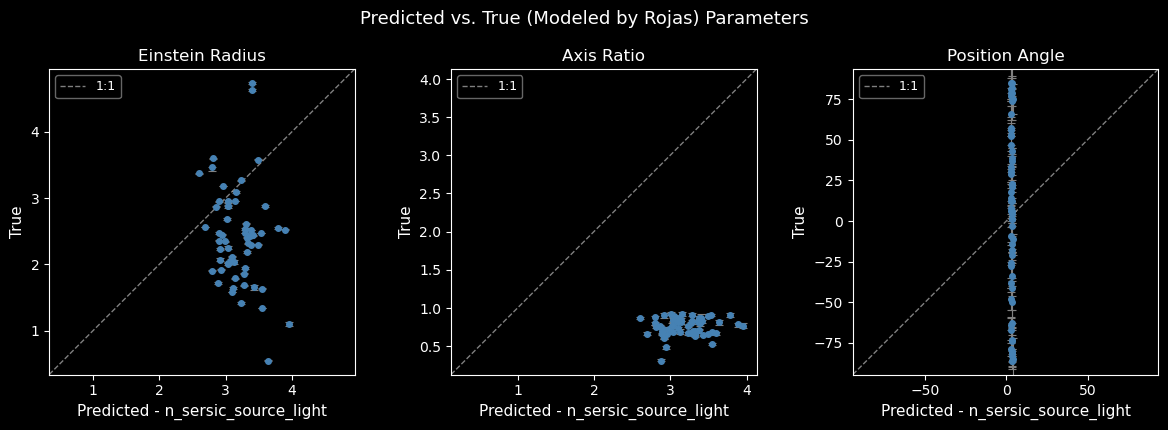

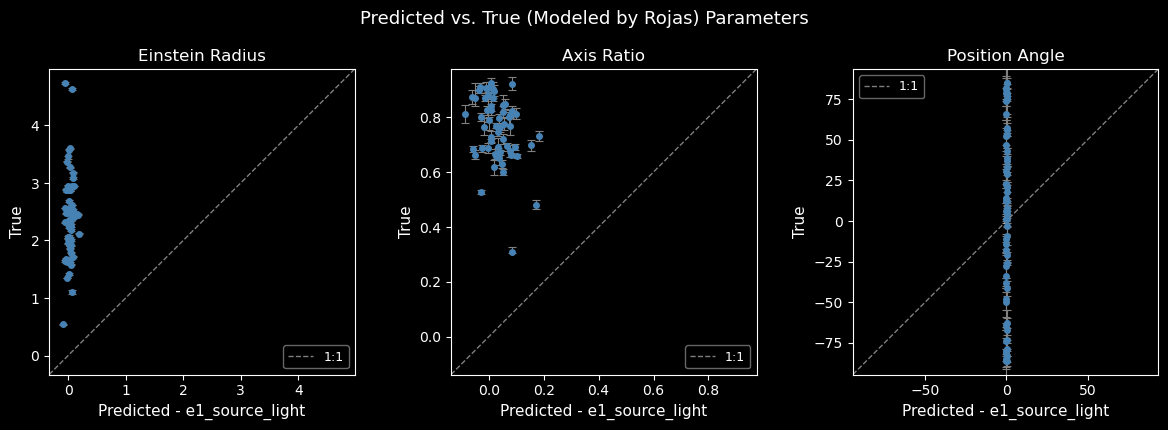

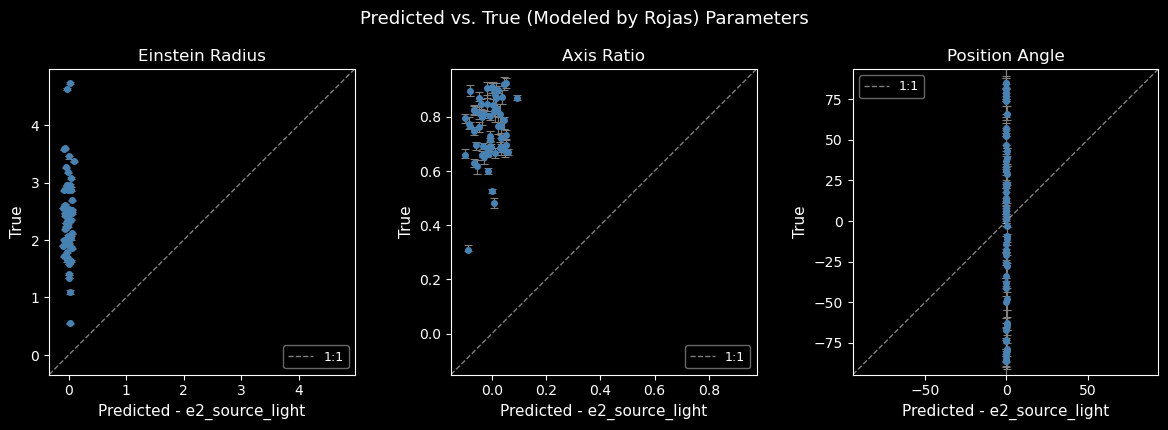

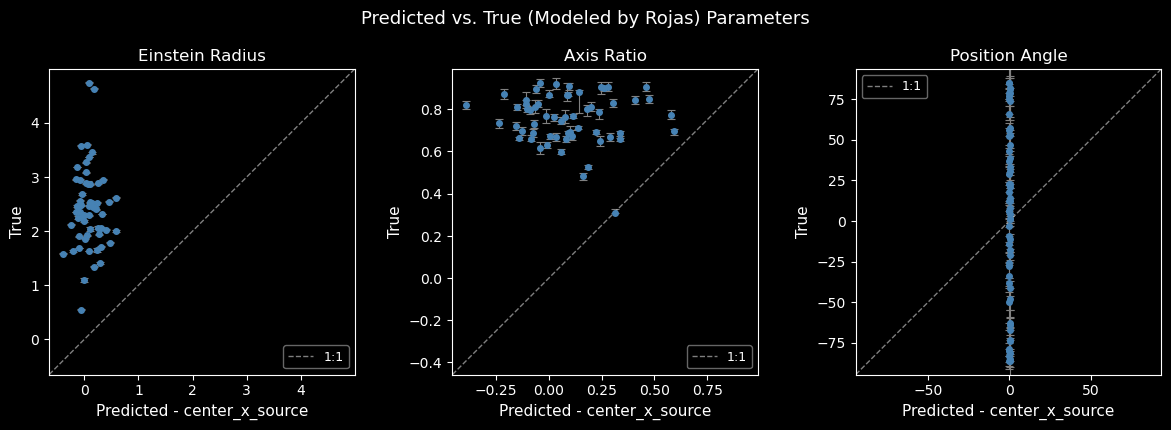

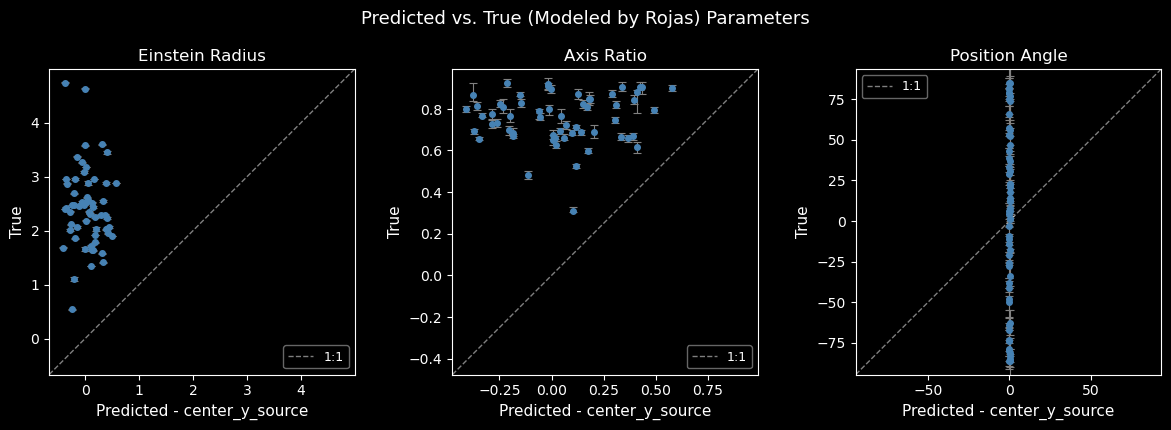

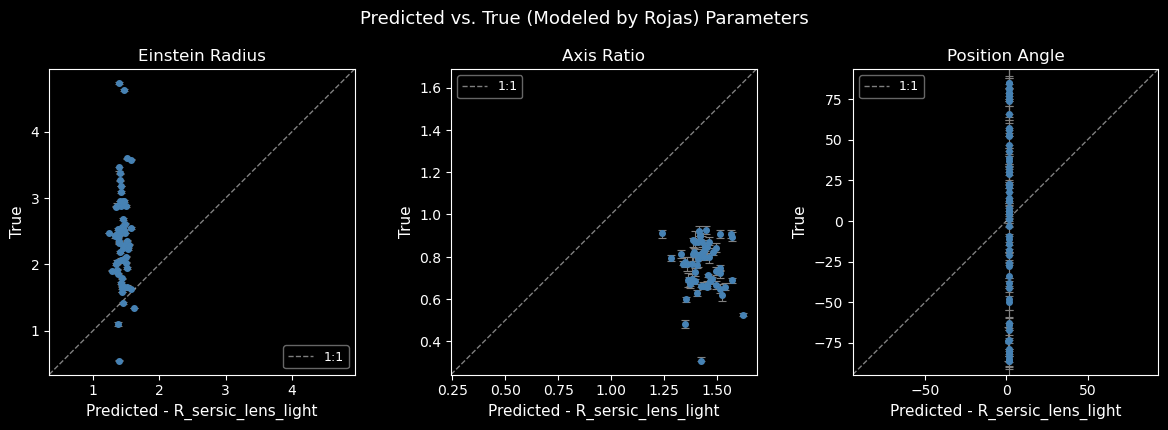

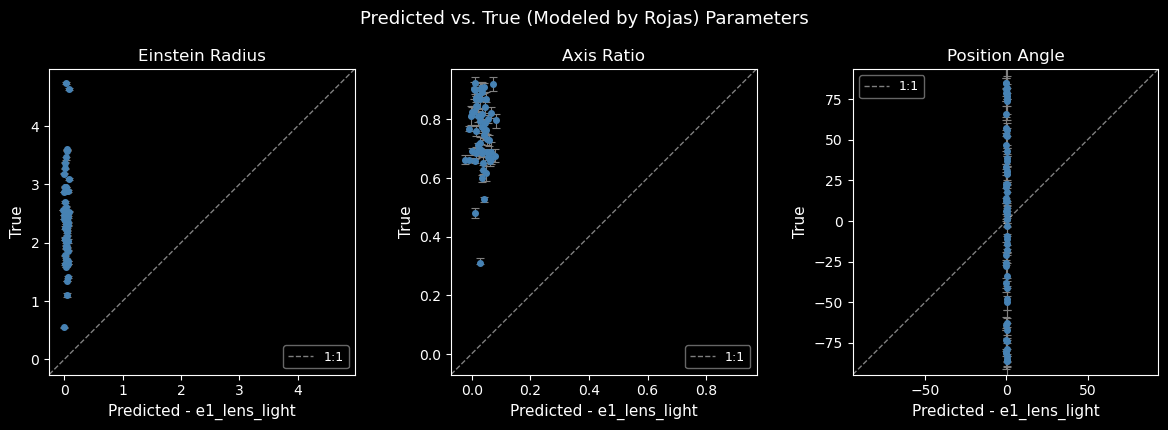

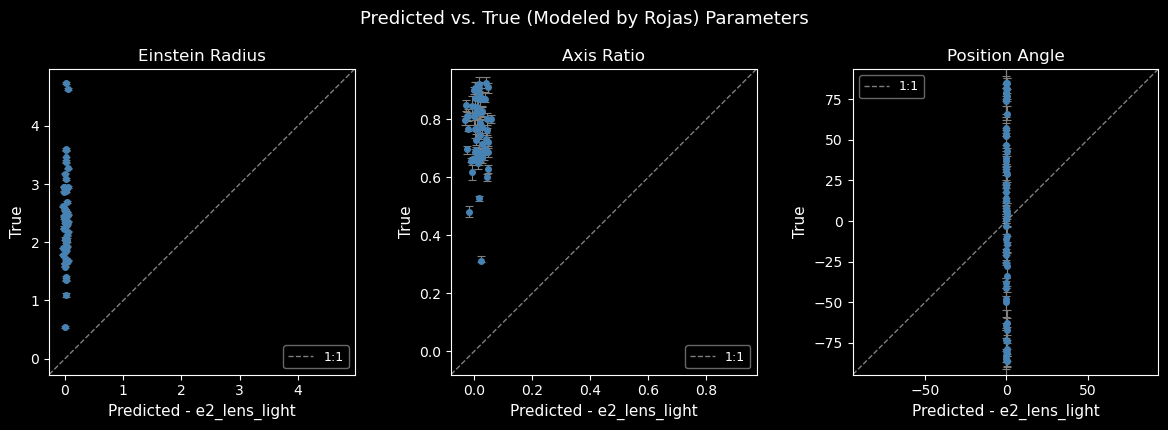

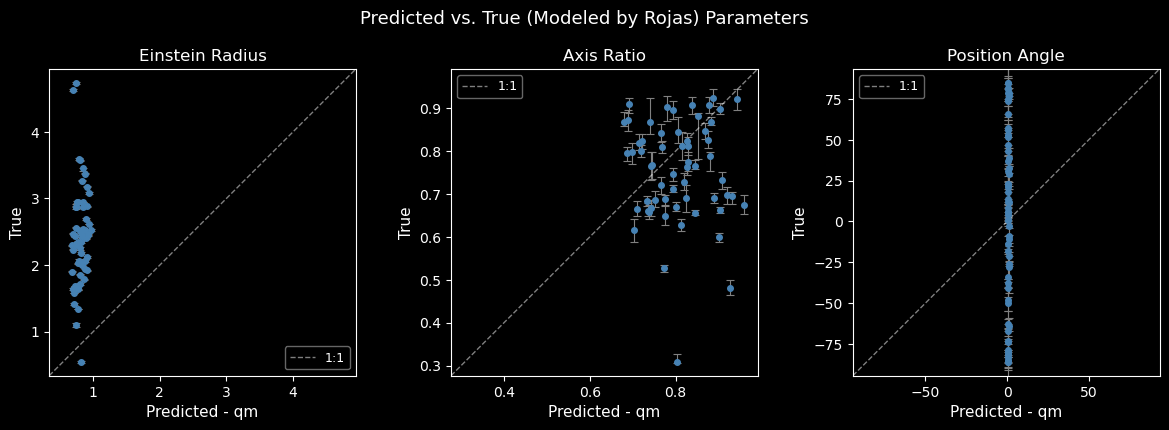

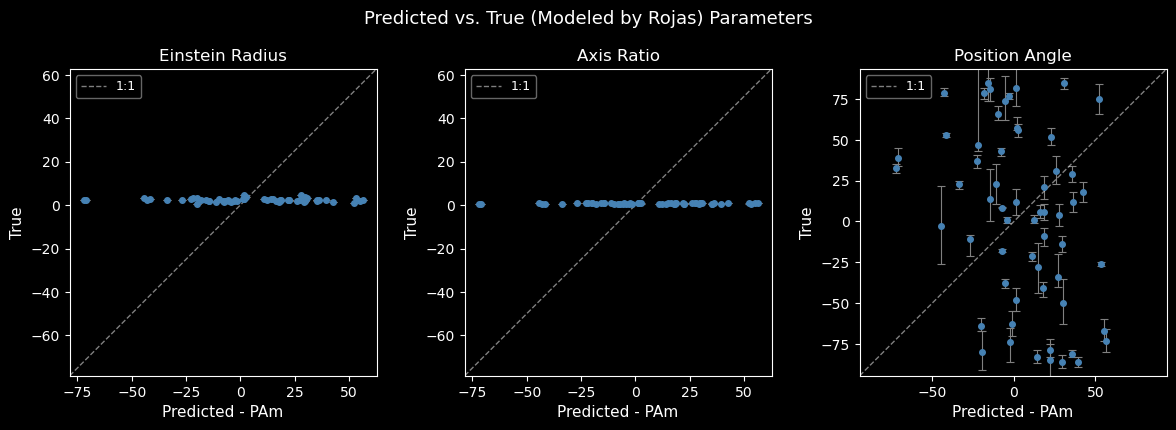

In [15]:
for column_pred in predicted_data.columns:
    titles = {'RE': 'Einstein Radius', 'qm': 'Axis Ratio', 'PAm': 'Position Angle'}

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    for ax, column in zip(axes, titles):
        yerr = [data['L_' + column], data['U_' + column]]
        ax.errorbar(predicted_data[column_pred], data[column], yerr=yerr, fmt='o', markersize=4, color='steelblue',
            ecolor='gray', elinewidth=0.8, capsize=3, capthick=0.8, alpha=1., linewidth=0)

        # 1:1 reference line
        all_vals = np.concatenate([predicted_data[column_pred], data[column]])
        lims = [all_vals.min(), all_vals.max()]
        margin = (lims[1] - lims[0]) * 0.05
        lims = [lims[0] - margin, lims[1] + margin]
        ax.plot(lims, lims, 'w--', linewidth=1, alpha=0.5, label='1:1')

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal')
        ax.set_title(titles[column], fontsize=12)
        ax.set_xlabel('Predicted - ' + column_pred, fontsize=11)
        ax.set_ylabel('True', fontsize=11)
        ax.tick_params(labelsize=10)
        ax.legend(fontsize=9, framealpha=0.5)

    plt.suptitle('Predicted vs. True (Modeled by Rojas) Parameters', fontsize=13, y=1.02)
    plt.tight_layout()
    #plt.savefig('figure.pdf', bbox_inches='tight', dpi=300)
    plt.show()